# Análisis TCRM (Tasa de Cambio Representativa del Mercado)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 1. Carga y limpieza de datos

El archivo original contiene 4 columnas:
- `VALOR`: tasa de cambio (COP por USD).
- `UNIDAD`: siempre `COP`.
- `VIGENCIADESDE` / `VIGENCIAHASTA`: rango de fechas en el que ese valor estuvo vigente
  (la TCRM se publica solo los días hábiles; el valor de un viernes, por ejemplo, sigue
  vigente el sábado y el domingo hasta la siguiente publicación).

Convertimos `VALOR` a `float`, convertimos las fechas y ordenamos cronológicamente.

In [5]:
df = pd.read_excel('Tasa_de_Cambio_Representativa_del__Mercado_Historico.xlsx')

df['VALOR'] = df['VALOR'].astype(str).str.replace(',', '', regex=False).astype(float)
df['VIGENCIADESDE'] = pd.to_datetime(df['VIGENCIADESDE'])
df['VIGENCIAHASTA'] = pd.to_datetime(df['VIGENCIAHASTA'])

df = df.sort_values('VIGENCIADESDE').reset_index(drop=True)

print(f"Número de registros (publicaciones): {len(df)}")
print(f"Rango de fechas: {df['VIGENCIADESDE'].min().date()}  ->  {df['VIGENCIAHASTA'].max().date()}")

Número de registros (publicaciones): 7188
Rango de fechas: 1991-12-02  ->  2021-10-19


In [6]:
df.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,643.42,COP,1991-12-02,1991-12-02
1,639.22,COP,1991-12-03,1991-12-03
2,635.70,COP,1991-12-04,1991-12-04
3,631.51,COP,1991-12-05,1991-12-05
4,627.16,COP,1991-12-06,1991-12-06


In [7]:
df.tail()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
7183,3765.80,COP,2021-10-09,2021-10-12
7184,3738.48,COP,2021-10-13,2021-10-13
7185,3725.75,COP,2021-10-14,2021-10-14
7186,3755.29,COP,2021-10-15,2021-10-15
7187,3772.49,COP,2021-10-16,2021-10-19


In [4]:
df.describe()

,VALOR,VIGENCIADESDE,VIGENCIAHASTA
count,7188.000000,7188,7188
mean,2096.580658,2006-09-21 10:19:25.943238,2006-09-21 22:46:04.607679
min,620.620000,1991-12-02 00:00:00,1991-12-02 00:00:00
25%,1584.137500,1999-03-12 18:00:00,1999-03-14 06:00:00
50%,2045.105000,2006-08-23 12:00:00,2006-08-23 12:00:00
75%,2743.230000,2014-03-20 06:00:00,2014-03-20 06:00:00
max,4153.910000,2021-10-16 00:00:00,2021-10-19 00:00:00
std,827.961028,NaN,NaN


## 2a. TCRM en la fecha de expedición de mi cédula (16 de enero de 2017)

Buscamos la fila cuyo rango de vigencia `[VIGENCIADESDE, VIGENCIAHASTA]` contiene esta fecha:


In [8]:
fecha_cedula = pd.Timestamp('2017-01-16')

fila = df[(df['VIGENCIADESDE'] <= fecha_cedula) & (df['VIGENCIAHASTA'] >= fecha_cedula)]
tcrm_cedula = fila['VALOR'].iloc[0]

print(f"Fecha consultada : {fecha_cedula.date()} ({fecha_cedula.day_name()})")
print(f"Vigencia del dato: {fila['VIGENCIADESDE'].iloc[0].date()} a {fila['VIGENCIAHASTA'].iloc[0].date()}")
print(f"TCRM             : $ {tcrm_cedula:,.2f} COP por USD")

Fecha consultada : 2017-01-16 (Monday)
Vigencia del dato: 2017-01-14 a 2017-01-17
TCRM             : $ 2,935.96 COP por USD


**Respuesta a):**  
El 16 de enero de 2017 la TCRM vigente fue de **$2.935,96 COP** por
dólar (dato publicado el 14 de enero de 2017, vigente hasta el 17 de enero por tratarse de
un fin de semana).


## 2b. Completitud de los datos:
¿Están completos los datos?,¿Cuántos días no se transaron?, cree una 
función para llenar los datos faltantes. 

1. **¿El histórico tiene huecos?** Es decir, ¿hay algún día calendario entre el mínimo y el
   máximo que no quede cubierto por ningún rango `[VIGENCIADESDE, VIGENCIAHASTA]`?
2. **¿Cuántos días no se transó?** Es decir, cuántos días calendario dentro del rango
   corresponden a fines de semana/festivos en los que la Superfinanciera no publicó un
   valor nuevo (el valor se "hereda" del último día hábil).

In [9]:
# 1. Verificar continuidad de los rangos de vigencia (sin huecos reales)
gaps = []
for i in range(len(df) - 1):
    fin_actual = df.loc[i, 'VIGENCIAHASTA']
    inicio_sig = df.loc[i + 1, 'VIGENCIADESDE']
    diferencia = (inicio_sig - fin_actual).days
    if diferencia != 1:
        gaps.append((fin_actual, inicio_sig, diferencia))

print(f"Discontinuidades encontradas entre rangos de vigencia: {len(gaps)}")

Discontinuidades encontradas entre rangos de vigencia: 0


Los datos SÍ están completos: cada rango empalma exactamente con el siguiente, por lo que no existen fechas calendario sin TCRM asignada.

In [6]:
# 2. Días calendario en los que NO hubo negociación/publicación (fines de semana y festivos)

total_dias_calendario = (df['VIGENCIAHASTA'].max() - df['VIGENCIADESDE'].min()).days + 1
n_publicaciones = len(df)
dias_no_transados = total_dias_calendario - n_publicaciones

print(f"Total de días calendario en el rango  : {total_dias_calendario:,}")
print(f"Días con publicación (días hábiles)   : {n_publicaciones:,}")
print(f"Días en que NO se transó (fin de semana / festivos): {dias_no_transados:,}")

df['dias_vigencia'] = (df['VIGENCIAHASTA'] - df['VIGENCIADESDE']).dt.days + 1
print("\nDistribución de la duración de cada vigencia (en días):")
print(df['dias_vigencia'].value_counts().sort_index())


Total de días calendario en el rango  : 10,915
Días con publicación (días hábiles)   : 7,188
Días en que NO se transó (fin de semana / festivos): 3,727

Distribución de la duración de cada vigencia (en días):
dias_vigencia
1    5529
2      91
3    1117
4     403
5      47
6       1
Name: count, dtype: int64


La columna `dias_vigencia` creada en la celda anterior, indica cuántos días calendario estuvo vigente cada valor publicado antes de que saliera uno nuevo. **1 día** (5.529 casos) es lo normal entre dos días hábiles seguidos; **3 días** (1.117 casos) corresponde a un fin de semana normal (el valor del viernes cubre viernes-sábado-domingo); **4 y 5 días** son fines de semana con uno o dos festivos pegados (puentes); y **2 y 6 días** son casos puntuales (un festivo suelto entre semana, o un cierre excepcionalmente largo). Sumando `(dias_vigencia - 1)` de todas las publicaciones se obtiene exactamente 3.727, el mismo número de días no transados calculado arriba.

**Respuesta b):**  
los datos **sí están completos** en el sentido de que no hay huecos
en la cobertura de fechas (cada rango de vigencia empalma con el siguiente). Sin embargo,
de los 10.915 días calendario comprendidos entre el 2 de diciembre de 1991 y el 19 de
octubre de 2021, solo 7.188 corresponden a publicaciones (días hábiles); es decir,
**3.727 días no se transó** (fueron fines de semana o festivos en los que la tasa del
último día hábil se mantuvo vigente).

A continuación se construye una función que recibe el dataframe de vigencias y devuelve
una **serie diaria completa** (un valor de TCRM para cada día calendario), rellenando los
días no transados con el último valor vigente, que es  el criterio oficial.


In [10]:
def llenar_datos_faltantes(df):
    """Expande un dataframe de vigencias de TCRM (columnas VALOR, VIGENCIADESDE, VIGENCIAHASTA)
    a una serie diaria continua, rellenando los días no hábiles (fines de semana/festivos)
    con el último valor vigente.

    Args:
        df : pd.DataFrame con columnas VALOR, VIGENCIADESDE, VIGENCIAHASTA

    Returns:
        pd.Series indexada por fecha diaria, sin valores faltantes.
    """
    idx_completo = pd.date_range(df['VIGENCIADESDE'].min(), df['VIGENCIAHASTA'].max(), freq='D')
    serie = pd.Series(index=idx_completo, dtype=float, name='TCRM')
    for _, fila in df.iterrows():
        serie.loc[fila['VIGENCIADESDE']:fila['VIGENCIAHASTA']] = fila['VALOR']
    serie = serie.ffill()  # seguridad ante cualquier hueco residual
    return serie

In [11]:
serie_tcrm = llenar_datos_faltantes(df)

print(f"Serie diaria completa: {len(serie_tcrm)} observaciones")
print(f"Valores faltantes tras el llenado: {serie_tcrm.isna().sum()}")

Serie diaria completa: 10915 observaciones
Valores faltantes tras el llenado: 0


In [12]:
serie_tcrm.head()

1991-12-02    643.42
1991-12-03    639.22
1991-12-04    635.70
1991-12-05    631.51
1991-12-06    627.16
Freq: D, Name: TCRM, dtype: float64

## 2c. Gráfico de la TCRM vs. el tiempo

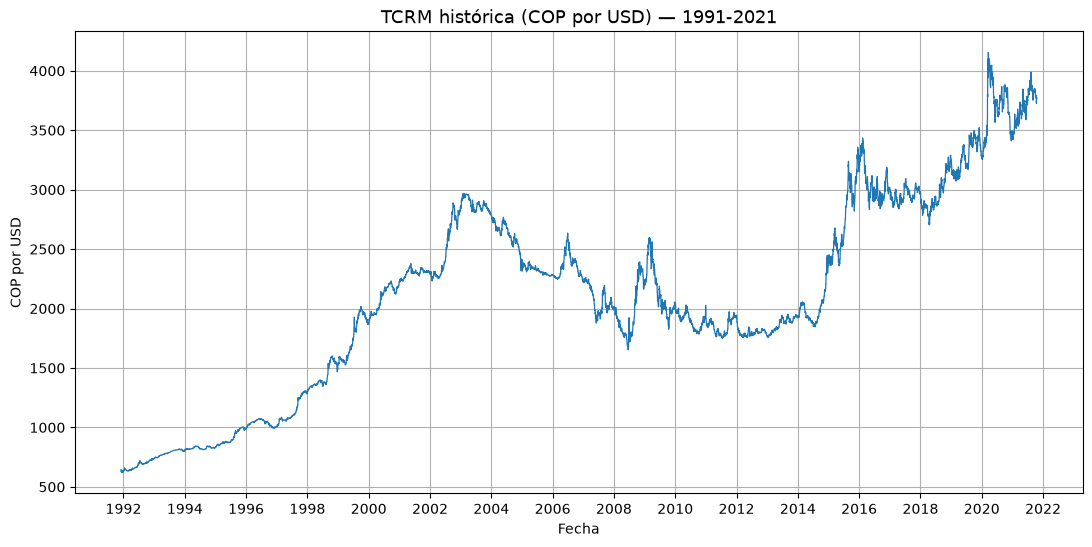

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_tcrm.index, serie_tcrm.values, color='#1f77b4', linewidth=0.9)
ax.set_title('TCRM histórica (COP por USD) — 1991-2021', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('COP por USD')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

### Análisis de la curva observada

Al observar la serie 1991–2021 se identifican varias fases claramente diferenciadas:

- **1991–1998:** devaluación gradual y relativamente ordenada, con el peso pasando de ~640 a cerca de 1.500 COP por dólar.
- **1998–2003:** fuerte y sostenida depreciación del peso (crisis económica de finales de los noventa), llevando la TCRM de ~1.500 a un pico cercano a 2.900 COP en 2003.
- **2003–2008:** tendencia de **revaluación** casi ininterrumpida, impulsada por altos precios del petróleo y entrada de capitales, hasta mínimos cercanos a 1.650–1.700 COP a mediados de 2008.
- **2008–2009:** repunte abrupto por la crisis financiera internacional, con la TCRM subiendo rápidamente por encima de 2.400 COP.
- **2009–2014:** nueva fase de apreciación del peso, apoyada en el auge de precios del petróleo y del carbón, llevando la tasa de nuevo a mínimos cercanos a 1.750–1.800 COP.
- **2014–2016:** es el movimiento más pronunciado de toda la serie: el colapso de los precios del petróleo genera una depreciación acelerada del peso, que pasa de ~1.900 COP a más de 3.400 COP en cerca de 18 meses (con un pico incluso por encima de 3.400 COP a comienzos de 2016).
- **2016–2019:** la tasa se estabiliza y oscila en un rango amplio, entre 2.850 y 3.300 COP.
- **2020:** nuevo salto abrupto por la pandemia de COVID-19 y la caída del precio del petróleo, con la TCRM superando los 4.100 COP a mediados de año (el máximo histórico de la serie).
- **2020–2021:** ligera corrección y estabilización alrededor de 3.700–3.800 COP.

En términos estadísticos, la serie **no es estacionaria**: presenta una clara tendencia de largo plazo al alza (devaluación estructural del peso frente al dólar) y **heterocedasticidad**, los períodos de crisis (1998-1999, 2008, 2014-2016, 2020) muestran una volatilidad de los retornos diarios varias veces mayor que en los períodos de calma. Esto es típico de series de tasas de cambio y tiene implicaciones directas sobre
cómo se debe modelar el pronóstico (ver punto d).

## 2d. Forecast de la TCRM para el 1 de enero de 2023

La última observación disponible en el histórico es el **19 de octubre de 2021**, por lo
que se debe pronosticar hacia adelante aproximadamente **315 días hábiles**
(1 de enero de 2023 cae en domingo; se usa como referencia el último día hábil antes de esa fecha).

Dado que la TCRM es una serie financiera altamente persistente y no estacionaria en nivel, se trabaja sobre el **logaritmo de la serie de días hábiles** (evitando duplicar el valor en los fines de semana, lo que inflaría artificialmente la
autocorrelación) y se ajusta un modelo **ARIMA**, seleccionado automáticamente por el criterio AIC.
Como validación cruzada se compara contra un modelo de referencia estándar en tasas de
cambio: la **Random Walk with Drift**.


In [16]:
import pmdarima as pm

# Serie de días hábiles (una observación por publicación real, sin duplicar fines de semana)
serie_habil = df.set_index('VIGENCIADESDE')['VALOR']
log_serie = np.log(serie_habil)

print(f"Observaciones (días hábiles): {len(serie_habil)}")
print(f"Último dato: {serie_habil.index[-1].date()}  ->  $ {serie_habil.iloc[-1]:,.2f}")

# Horizonte de pronóstico en días hábiles hasta el 1 de enero de 2023
horizonte = len(pd.bdate_range(serie_habil.index[-1] + pd.Timedelta(days=1), '2023-01-01'))
print(f"Horizonte de pronóstico: {horizonte} días hábiles")

Observaciones (días hábiles): 7188
Último dato: 2021-10-16  ->  $ 3,772.49
Horizonte de pronóstico: 315 días hábiles


In [17]:
modelo_arima = pm.auto_arima(
    log_serie, seasonal=False, stepwise=True, suppress_warnings=True,
    max_p=5, max_q=5, max_d=2, information_criterion='aic', trace=False
)
print(modelo_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 7188
Model:               SARIMAX(1, 1, 0)   Log Likelihood               26248.499
Date:                Wed, 26 Aug 2026   AIC                         -52490.997
Time:                        02:04:04   BIC                         -52470.357
Sample:                             0   HQIC                        -52483.895
                               - 7188                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0002   7.46e-05      2.748      0.006    5.87e-05       0.000
ar.L1          0.1714      0.006     28.470      0.000       0.160       0.183
sigma2      3.937e-05   2.87e-07    137.393      0.0

In [18]:
log_fc, ic_log = modelo_arima.predict(n_periods=horizonte, return_conf_int=True, alpha=0.05)
fc_nivel = np.exp(log_fc)

pronostico_arima = fc_nivel.iloc[-1]
ic_log_final = ic_log[-1]
# Error estándar en log a partir del intervalo de confianza al 95%
se_log = (ic_log_final[1] - ic_log_final[0]) / (2 * 1.959963985)
# Aproximación delta: sd en nivel ≈ nivel_esperado * sd_log
sd_arima = pronostico_arima * se_log

print(f"Pronóstico ARIMA TCRM 1-ene-2023   : $ {pronostico_arima:,.2f} COP")
print(f"Desviación estándar estimada (ARIMA): $ {sd_arima:,.2f} COP")


Pronóstico ARIMA TCRM 1-ene-2023   : $ 4,081.63 COP
Desviación estándar estimada (ARIMA): $ 548.25 COP


D:\prueba-pragma\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [19]:
# Modelo de referencia: Random Walk con Drift (log-retornos)
log_retornos = log_serie.diff().dropna()
mu = log_retornos.mean()
sigma = log_retornos.std()

ultimo_valor = serie_habil.iloc[-1]
pronostico_rw = ultimo_valor * np.exp(mu * horizonte)
sd_rw = pronostico_rw * (sigma * np.sqrt(horizonte))

print(f"Deriva diaria (mu)     : {mu:.6f}")
print(f"Volatilidad diaria (σ) : {sigma:.6f}")
print(f"Pronóstico RW con deriva TCRM 1-ene-2023: $ {pronostico_rw:,.2f} COP")
print(f"Desviación estándar estimada (RW)        : $ {sd_rw:,.2f} COP")


Deriva diaria (mu)     : 0.000246
Volatilidad diaria (σ) : 0.006370
Pronóstico RW con deriva TCRM 1-ene-2023: $ 4,076.57 COP
Desviación estándar estimada (RW)        : $ 460.87 COP


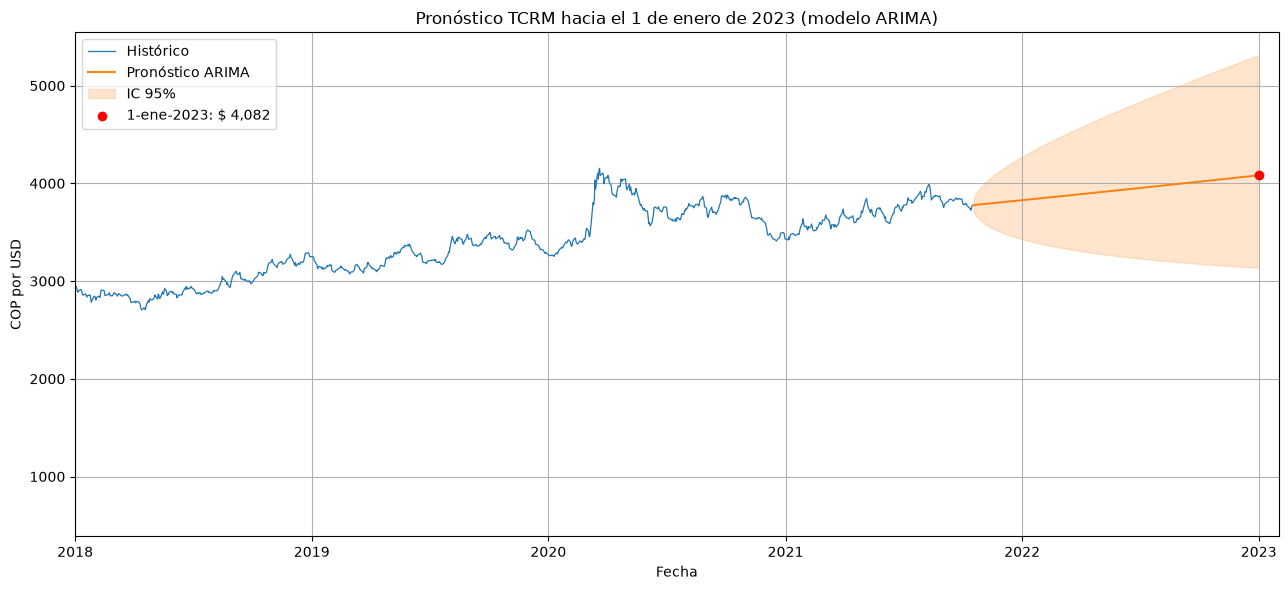

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_habil.index, serie_habil.values, label='Histórico', color='#1f77b4', linewidth=0.9)

fechas_fc = pd.bdate_range(serie_habil.index[-1] + pd.Timedelta(days=1), '2023-01-01')
ax.plot(fechas_fc, fc_nivel.values, label='Pronóstico ARIMA', color='#ff7f0e', linewidth=1.4)
ax.fill_between(fechas_fc, np.exp(ic_log[:, 0]), np.exp(ic_log[:, 1]),
                color='#ff7f0e', alpha=0.2, label='IC 95%')
ax.scatter([pd.Timestamp('2023-01-01')], [pronostico_arima], color='red', zorder=5,
           label=f'1-ene-2023: $ {pronostico_arima:,.0f}')

ax.set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2023-02-01'))
ax.set_title('Pronóstico TCRM hacia el 1 de enero de 2023 (modelo ARIMA)')
ax.set_xlabel('Fecha')
ax.set_ylabel('COP por USD')
ax.legend()
plt.tight_layout()
plt.show()

### Resumen de resultados del forecast

| Modelo | Pronóstico TCRM 1-ene-2023 | Desviación estándar estimada |
|---|---|---|
| ARIMA(1,1,0) con deriva (seleccionado por AIC) | ≈ 4.082 COP | ≈ 548 COP |
| Random Walk con deriva (referencia) | ≈ 4.077 COP | ≈ 461 COP |

Los dos enfoques coinciden razonablemente (~$4.075–4.080 COP), lo cual es consistente con
la teoría financiera: para series de tipo de cambio, que se comportan aproximadamente como
una caminata aleatoria, un modelo ARIMA de bajo orden termina siendo, en la práctica, muy
similar a una caminata aleatoria con deriva.

**Respuesta d):**  
De acuerdo con el histórico, el modelo ARIMA(1,1,0) con deriva ajustado
sobre el logaritmo de la TCRM estima un valor de **aproximadamente 4.082 COP** por dólar
para el 1 de enero de 2023, con una **desviación estándar estimada de aproximadamente
548 COP**. Un modelo de referencia de caminata aleatoria con deriva arroja un resultado
muy similar (≈ 4.077 COP, desviación estándar ≈ 461 COP), lo que da robustez a la
estimación puntual, aunque el amplio intervalo de confianza deja claro que a este
horizonte el pronóstico debe tomarse como una referencia de orden de magnitud y no como un
valor preciso.